In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from kfp import dsl
from scipy import stats

In [36]:
file_path = "/Users/aryaneuse/Desktop/Teh Rping/second-Tehran-Encroachment/data/raw/DATASET.xlsx"

In [37]:
@dsl.component(packages_to_install=['openpyxl', 'pandas'])
def read_excel_component(file_path: str):
    import pandas as pd
    df = pd.read_excel(file_path)
    print(df.head())
    return df

/var/folders/m2/8_8g8y_914dgb35s009kyvy40000gn/T/ipykernel_78113/945662959.py:1: FutureWarning: The default base_image used by the @dsl.component decorator will switch from 'python:3.11' to 'python:3.12' on Oct 1, 2027. To ensure your existing components work with versions of the KFP SDK released after that date, you should provide an explicit base_image argument and ensure your component works as intended on Python 3.12.
  @dsl.component(packages_to_install=['openpyxl', 'pandas'])


In [38]:
from kfp import dsl

@dsl.component(
    packages_to_install=['openpyxl', 'pandas'],
    base_image='python:3.11'
)
def read_excel_file(file_path: str):
    import pandas as pd
    
    # خوندن فایل
    df = pd.read_excel(file_path, engine='openpyxl')
    
    # نمایش اطلاعات
    print("✅ فایل با موفقیت خوندش!")
    print(f"تعداد ردیف‌ها: {len(df)}")
    print(f"تعداد ستون‌ها: {len(df.columns)}")
    print("\n۵ ردیف اول:")
    print(df.head())
    
    # اگه فایل فارسی هست
    for col in df.select_dtypes(include=['object']).columns:
        try:
            df[col] = df[col].astype(str).str.encode('cp1256').str.decode('utf-8', errors='ignore')
        except:
            pass
    
    return df

In [39]:
df = pd.read_excel(file_path, engine='openpyxl')

In [40]:
# نمایش ۵ ردیف اول
print(df.head())

# اطلاعات کلی
print(df.info())

# آمار توصیفی
print(df.describe())

# تعداد ردیف‌ها و ستون‌ها
print(f"شکل دیتافریم: {df.shape}")

  Customer_ID Location_ID Customer_Segment Relationship_Start_Date  \
0    C_009817     LOC-012                B              2020-07-20   
1    C_010119     LOC-001                C              2020-02-24   
2    C_010649     LOC-007                B              2020-03-30   
3    C_011055     LOC-006                A              2020-05-25   
4    C_014775     LOC-002                A              2020-09-07   

   Credit_Limit  Payment_Terms_Days Customer_Status Source_System Sales_Rep_ID  
0         35000                   0         غیرفعال           MDM      REP-003  
1         43000                   0         غیرفعال           MDM      REP-003  
2       5630000                   0            فعال           MDM      REP-008  
3         84000                   0            فعال           MDM      REP-002  
4        789000                   0         غیرفعال           MDM      REP-004  
<class 'pandas.DataFrame'>
RangeIndex: 644 entries, 0 to 643
Data columns (total 9 columns):


In [41]:
# تنظیمات نمایش فارسی
plt.rcParams['font.family'] = 'DejaVu Sans'

# آمار توصیفی کامل
print("="*50)
print("📊 آمار توصیفی ستون‌های عددی:")
print(df[['Credit_Limit', 'Payment_Terms_Days']].describe())

# بررسی چولگی (Skewness)
print("\n📈 چولگی (Skewness):")
print(df[['Credit_Limit', 'Payment_Terms_Days']].skew())

# بررسی کشیدگی (Kurtosis)
print("\n📉 کشیدگی (Kurtosis):")
print(df[['Credit_Limit', 'Payment_Terms_Days']].kurtosis())

📊 آمار توصیفی ستون‌های عددی:
       Credit_Limit  Payment_Terms_Days
count  6.440000e+02          644.000000
mean   2.494701e+08            8.478261
std    1.661906e+09           20.815740
min    5.000000e+03            0.000000
25%    7.900000e+04            0.000000
50%    3.670000e+05            0.000000
75%    1.348750e+06            0.000000
max    1.800000e+10           90.000000

📈 چولگی (Skewness):
Credit_Limit          8.164115
Payment_Terms_Days    2.785758
dtype: float64

📉 کشیدگی (Kurtosis):
Credit_Limit          73.341593
Payment_Terms_Days     7.388652
dtype: float64


In [42]:
# ستون‌های دسته‌ای
categorical_cols = ['Customer_Segment', 'Customer_Status', 'Source_System', 'Sales_Rep_ID', 'Location_ID']

for col in categorical_cols:
    print(f"\n📌 {col}:")
    print(df[col].value_counts())
    print(f"تعداد Unique: {df[col].nunique()}")
    print("-"*30)

# درصدی
for col in categorical_cols:
    print(f"\n📊 درصد {col}:")
    print(df[col].value_counts(normalize=True).mul(100).round(2))
    print("-"*30)


📌 Customer_Segment:
Customer_Segment
A    231
C    207
B    206
Name: count, dtype: int64
تعداد Unique: 3
------------------------------

📌 Customer_Status:
Customer_Status
غیرفعال    371
فعال       273
Name: count, dtype: int64
تعداد Unique: 2
------------------------------

📌 Source_System:
Source_System
MDM           624
CRM_MASTER     20
Name: count, dtype: int64
تعداد Unique: 2
------------------------------

📌 Sales_Rep_ID:
Sales_Rep_ID
REP-003    90
REP-002    89
REP-007    85
REP-005    81
REP-008    77
REP-004    77
REP-006    74
REP-001    71
Name: count, dtype: int64
تعداد Unique: 8
------------------------------

📌 Location_ID:
Location_ID
LOC-007    49
LOC-014    47
LOC-009    46
LOC-004    46
LOC-011    44
LOC-012    43
LOC-003    43
LOC-015    43
LOC-002    42
LOC-006    41
LOC-001    37
LOC-005    37
LOC-016    34
LOC-013    32
LOC-008    32
LOC-010    28
Name: count, dtype: int64
تعداد Unique: 16
------------------------------

📊 درصد Customer_Segment:
Customer_Segmen

💰 سقف اعتبار بر اساس سگمنت:
                          mean    median          max   min  count
Customer_Segment                                                  
A                 9.614270e+07  309000.0   4000000000  5000    231
B                 4.088160e+08  414000.0  12000000000  5000    206
C                 2.619985e+08  360000.0  18000000000  5000    207


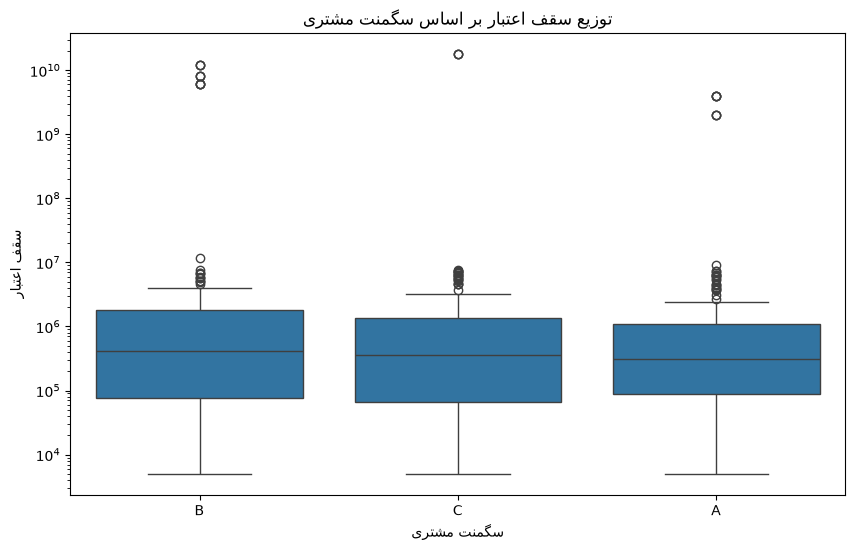


🔬 ANOVA: F-statistic=1.942, p-value=0.14432
❌ تفاوت معنی‌دار بین سگمنت‌ها وجود نداره


In [49]:
# سگمنت مشتری و سقف اعتبار
print("="*50)
print("💰 سقف اعتبار بر اساس سگمنت:")
print(df.groupby('Customer_Segment')['Credit_Limit'].agg(['mean', 'median', 'max', 'min', 'count']))

# باکس‌پلات
plt.figure(figsize=(10, 6))
sns.boxplot(x='Customer_Segment', y='Credit_Limit', data=df)
plt.title('توزیع سقف اعتبار بر اساس سگمنت مشتری')
plt.ylabel('سقف اعتبار')
plt.xlabel('سگمنت مشتری')
plt.yscale('log')  # چون داده‌ها چوله هستن
plt.show()

# تست آماری (ANOVA)
groups = [df[df['Customer_Segment'] == seg]['Credit_Limit'] for seg in df['Customer_Segment'].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\n🔬 ANOVA: F-statistic={f_stat:.3f}, p-value={p_value:.5f}")
if p_value < 0.05:
    print("✅ تفاوت معنی‌دار بین سگمنت‌ها وجود داره")
else:
    print("❌ تفاوت معنی‌دار بین سگمنت‌ها وجود نداره")

💰 سقف اعتبار بر اساس سگمنت:
                          mean    median          max   min  count
Customer_Segment                                                  
A                 9.614270e+07  309000.0   4000000000  5000    231
B                 4.088160e+08  414000.0  12000000000  5000    206
C                 2.619985e+08  360000.0  18000000000  5000    207


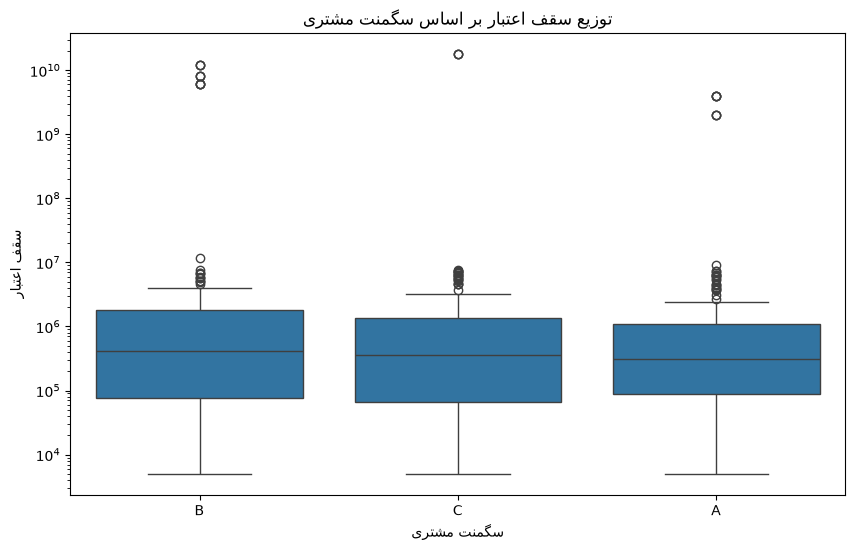


🔬 ANOVA: F-statistic=1.942, p-value=0.14432
❌ تفاوت معنی‌دار بین سگمنت‌ها وجود نداره


In [49]:
# سگمنت مشتری و سقف اعتبار
print("="*50)
print("💰 سقف اعتبار بر اساس سگمنت:")
print(df.groupby('Customer_Segment')['Credit_Limit'].agg(['mean', 'median', 'max', 'min', 'count']))

# باکس‌پلات
plt.figure(figsize=(10, 6))
sns.boxplot(x='Customer_Segment', y='Credit_Limit', data=df)
plt.title('توزیع سقف اعتبار بر اساس سگمنت مشتری')
plt.ylabel('سقف اعتبار')
plt.xlabel('سگمنت مشتری')
plt.yscale('log')  # چون داده‌ها چوله هستن
plt.show()

# تست آماری (ANOVA)
groups = [df[df['Customer_Segment'] == seg]['Credit_Limit'] for seg in df['Customer_Segment'].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\n🔬 ANOVA: F-statistic={f_stat:.3f}, p-value={p_value:.5f}")
if p_value < 0.05:
    print("✅ تفاوت معنی‌دار بین سگمنت‌ها وجود داره")
else:
    print("❌ تفاوت معنی‌دار بین سگمنت‌ها وجود نداره")

📊 وضعیت مشتری ('فعال' vs 'غیرفعال'):
Customer_Status
غیرفعال    371
فعال       273
Name: count, dtype: int64

📌 وضعیت بر اساس سگمنت:
Customer_Segment    A    B    C
Customer_Status                
غیرفعال           140  108  123
فعال               91   98   84

💰 میانگین سقف اعتبار بر اساس وضعیت:
Customer_Status
غیرفعال    4.146146e+05
فعال       5.879302e+08
Name: Credit_Limit, dtype: float64


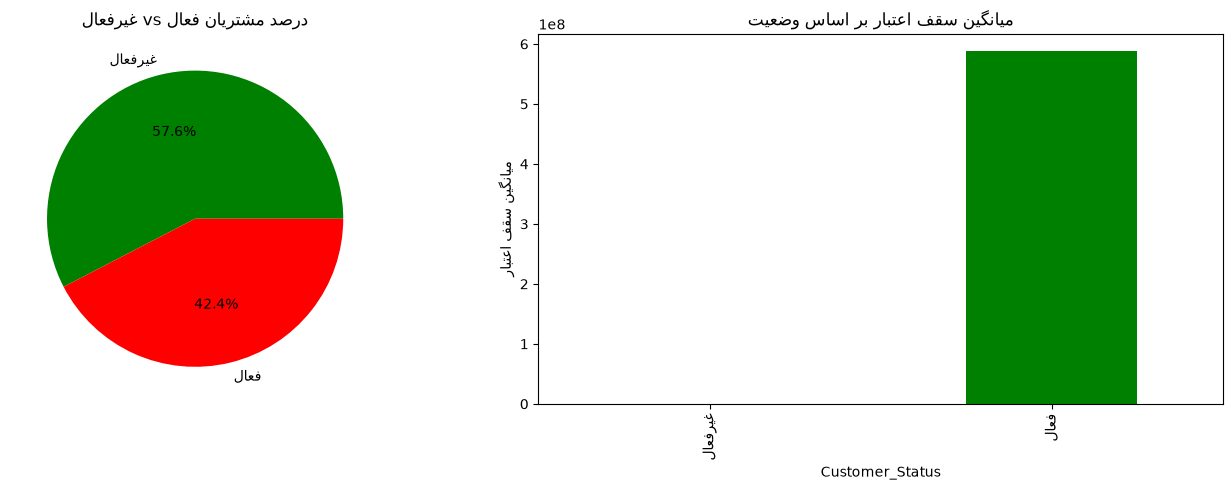

In [50]:
print("="*50)
print("📊 وضعیت مشتری ('فعال' vs 'غیرفعال'):")

# توزیع وضعیت
print(df['Customer_Status'].value_counts())

# رابطه با سگمنت
print("\n📌 وضعیت بر اساس سگمنت:")
print(pd.crosstab(df['Customer_Status'], df['Customer_Segment']))

# رابطه با سقف اعتبار
print("\n💰 میانگین سقف اعتبار بر اساس وضعیت:")
print(df.groupby('Customer_Status')['Credit_Limit'].mean())

# نمودار
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# درصد وضعیت
df['Customer_Status'].value_counts().plot.pie(ax=axes[0], autopct='%1.1f%%', 
                                               colors=['green', 'red'])
axes[0].set_title('درصد مشتریان فعال vs غیرفعال')
axes[0].set_ylabel('')

# میانگین سقف اعتبار
df.groupby('Customer_Status')['Credit_Limit'].mean().plot.bar(ax=axes[1], 
                                                               color=['red', 'green'])
axes[1].set_title('میانگین سقف اعتبار بر اساس وضعیت')
axes[1].set_ylabel('میانگین سقف اعتبار')
plt.tight_layout()
plt.show()

In [51]:
print("="*50)
print("📍 تحلیل موقعیت مکانی:")

# تعداد مشتریان هر موقعیت
location_stats = df.groupby('Location_ID').agg({
    'Customer_ID': 'count',
    'Credit_Limit': ['mean', 'sum'],
    'Customer_Status': lambda x: (x == 'فعال').sum() / len(x) * 100
}).round(2)
location_stats.columns = ['تعداد', 'میانگین اعتبار', 'مجموع اعتبار', 'درصد فعال']
print(location_stats.sort_values('تعداد', ascending=False).head(10))

# موقعیت‌های با بیشترین اعتبار
top_locations = df.groupby('Location_ID')['Credit_Limit'].sum().sort_values(ascending=False).head(5)
print("\n🏆 ۵ موقعیت با بیشترین مجموع اعتبار:")
print(top_locations)

📍 تحلیل موقعیت مکانی:
             تعداد  میانگین اعتبار  مجموع اعتبار  درصد فعال
Location_ID                                                
LOC-007         49    9.498571e+05      46543000      46.94
LOC-014         47    3.414024e+08   16045914000      42.55
LOC-004         46    1.313342e+08    6041372000      52.17
LOC-009         46    4.355791e+08   20036640000      43.48
LOC-011         44    1.829243e+08    8048668000      34.09
LOC-003         43    4.794721e+07    2061730000      41.86
LOC-012         43    1.356698e+06      58338000      34.88
LOC-015         43    5.592791e+08   24049003000      32.56
LOC-002         42    7.151152e+08   30034840000      47.62
LOC-006         41    1.000976e+06      41040000      39.02

🏆 ۵ موقعیت با بیشترین مجموع اعتبار:
Location_ID
LOC-002    30034840000
LOC-015    24049003000
LOC-009    20036640000
LOC-016    18016778000
LOC-001    16051151000
Name: Credit_Limit, dtype: int64


📅 تحلیل زمانی:

📌 تعداد مشتریان جدید در هر سال:
Year
1394      2
1395      2
1396      2
1397      2
1398      2
1399      2
1400      2
1401      2
1402      2
1403      2
2019     38
2020    410
2021    140
2022     36
Name: count, dtype: int64

💰 میانگین اعتبار بر اساس سال شروع همکاری:
Year
1394    9.000000e+09
1395    1.100000e+10
1396    4.000000e+09
1397    6.000000e+09
1398    9.000000e+09
1399    1.300000e+10
1400    7.000000e+09
1401    1.100000e+10
1402    4.000000e+09
1403    6.000000e+09
2019    1.742868e+06
2020    9.413878e+05
2021    1.088843e+06
2022    1.503278e+06
Name: Credit_Limit, dtype: float64


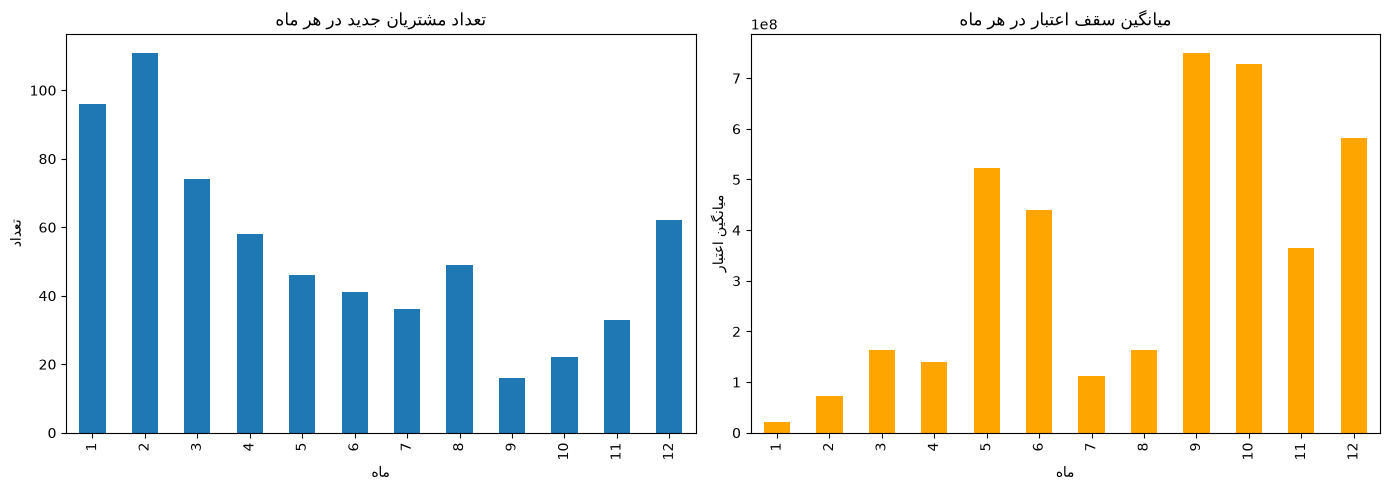

In [53]:
# تبدیل به تاریخ با format='mixed'
df['Relationship_Start_Date'] = pd.to_datetime(
    df['Relationship_Start_Date'], 
    format='mixed',  # خودش تشخیص بده
    dayfirst=False
)
# تبدیل به تاریخ
df['Relationship_Start_Date'] = pd.to_datetime(df['Relationship_Start_Date'])

# استخراج ویژگی‌های زمانی
df['Year'] = df['Relationship_Start_Date'].dt.year
df['Month'] = df['Relationship_Start_Date'].dt.month
df['Quarter'] = df['Relationship_Start_Date'].dt.quarter
df['DayOfWeek'] = df['Relationship_Start_Date'].dt.dayofweek

print("="*50)
print("📅 تحلیل زمانی:")

# تعداد مشتریان جدید بر اساس سال
print("\n📌 تعداد مشتریان جدید در هر سال:")
print(df['Year'].value_counts().sort_index())

# میانگین اعتبار بر اساس سال
print("\n💰 میانگین اعتبار بر اساس سال شروع همکاری:")
print(df.groupby('Year')['Credit_Limit'].mean())

# نمودار
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# تعداد مشتریان در ماه
df['Month'].value_counts().sort_index().plot.bar(ax=axes[0])
axes[0].set_title('تعداد مشتریان جدید در هر ماه')
axes[0].set_xlabel('ماه')
axes[0].set_ylabel('تعداد')

# میانگین اعتبار در ماه
df.groupby('Month')['Credit_Limit'].mean().plot.bar(ax=axes[1], color='orange')
axes[1].set_title('میانگین سقف اعتبار در هر ماه')
axes[1].set_xlabel('ماه')
axes[1].set_ylabel('میانگین اعتبار')
plt.tight_layout()
plt.show()